# t-SNE

**t-SNE** (t-distributed Stochastic Neighbor Embedding) is a powerful algorithm for **visualizing high-dimensional data** in 2D or 3D. It's particularly useful for exploring structure, spotting clusters, and gaining intuition about complex datasets such as images, word embeddings, or biological measurements.

t-SNE aims to answer the question: **"Can we find a 2D map of the data where pairs of points that are similar in the original space stay close, and dissimilar points are pushed apart?"**

<br>

<p align="center">
<img src="visualizations/tSNE.png" width="1000">
</p>

## Mathematical Foundation

### Model Local Similarity in High-D with Gaussians

For every point $x_i$, t-SNE defines a conditional probability that another point $x_j$ is its neighbor:

$$
p_{j|i} = \frac{\exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma_i^2}\right)}{\sum_{k \neq i} \exp\left(-\frac{\|x_i - x_k\|^2}{2\sigma_i^2}\right)}
$$

This is a **softmax over distances** — closer points have higher probability. The bandwidth $\sigma_i$ is found **individually per point** via binary search to match a target **perplexity**, which controls the effective number of neighbors (typically between 5 and 50).

**Symmetrization:** To create a proper **joint similarity distribution**:
$$
p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}
$$

Now $p_{ij} = p_{ji}$ and $\sum_{i \neq j} p_{ij} = 1$, making this a valid probability distribution over unordered point pairs.

### Model Similarity in Low-D with a Student-t Kernel

In the 2D or 3D embedding, we define similarities using the **Student-t distribution with 1 degree of freedom** (also known as a Cauchy kernel):

$$
q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}
$$

This is **symmetric by design** — and critically, it uses a **heavy-tailed** distribution.

**Why Student-t?** Using a Gaussian in low-D space leads to the **crowding problem** (There's not enough room in 2D to represent mid-distance relationships accurately — everything gets pulled into the center). The **heavy tails of the Student-t** fix this:
- Nearby points still get high similarity (like with Gaussians)
- Mid- and far-distance points retain **repulsive influence**, avoiding excessive compression

## Algorithm Steps

### Minimize the Mismatch: KL Divergence

t-SNE defines a cost function using the **Kullback–Leibler (KL) divergence** between the high-D similarities $p_{ij}$ and the low-D similarities $q_{ij}$:

$$
\text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}
$$

This divergence:
- **Strongly penalizes** placing close high-D points far apart in low-D
- **Forgives** pulling distant high-D points too close — allowing some overlap if needed

In other words, t-SNE preserves **local neighborhoods** but sacrifices **global distances**.

## Advanced Topics

### Bandwidth, β, and Perplexity

* We define $\beta_i = \frac{1}{2\sigma_i^2}$
* For each point $x_i$, t-SNE seeks the $\beta_i$ that makes the **Shannon entropy** of the distribution $p_{j|i}$ equal to $\log(\text{perplexity})$
* If you have entropy $H$ bits, you can think of it as "I have as much uncertainty as if I chose uniformly among $2^H$ items." That leads to the definition:

$$
\text{Perp}(P_i) = 2^{H(P_i)}, \quad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}
$$

* A **binary search** over $\beta_i$ adjusts the sharpness of the Gaussian:
  - If the entropy $H(P_i)$ is **too high** (distribution too flat), increase $\beta_i$ (sharpen the Gaussian)
  - If $H(P_i)$ is **too low** (distribution too peaky), decrease $\beta_i$ (widen the Gaussian)
* This per-point tuning ensures each point's neighborhood has roughly the same "effective size," adapting to varying data densities

### Final Takeaway

**t-SNE constructs a probability distribution over pairs of points in high-dimensional space (using Gaussians with adaptive width), and a similar distribution in low-dimensional space (using Student-t). It then optimizes the low-dimensional map to make these two distributions as similar as possible — focusing on preserving local structure while visually separating clusters.**

It models high-D neighborhoods with **adaptive Gaussians**, and matches them in low-D using **fixed, heavy-tailed Student-t kernels**, balancing attraction and repulsion through a probabilistic lens.

**It's not a general-purpose dimensionality reducer.** It's a visualization tool — not for feeding into classifiers.

In [6]:
import numpy as np

def compute_pairwise_distances(X):
    """Compute squared Euclidean distance matrix for input X."""
    sum_X = np.sum(np.square(X), axis=1)
    D = -2 * np.dot(X, X.T) + sum_X[:, np.newaxis] + sum_X[np.newaxis, :]
    return D

def _Hbeta(D, beta=1.0):
    """
    Compute entropy H and P-row given distances D and precision beta.
    Used in binary search to match a given perplexity.
    """
    P = np.exp(-D * beta)
    sumP = np.sum(P)
    H = np.log(sumP) + beta * np.sum(D * P) / sumP  # Shannon entropy
    return H, P / sumP

def compute_gaussian_perplexity(D, perplexity=30.0, tol=1e-5):
    """
    For each point i, compute conditional probability p_j|i using a Gaussian kernel.
    Tune sigma (via beta = 1/(2*sigma^2)) to achieve target perplexity using binary search.
    """
    n = D.shape[0]
    P = np.zeros((n, n))
    logU = np.log(perplexity)

    for i in range(n):
        betamin, betamax = -np.inf, np.inf
        beta = 1.0
        Di = np.delete(D[i], i)  # remove self-distance
        H, thisP = _Hbeta(Di, beta)

        # Binary search to match entropy to log(perplexity)
        Hdiff = H - logU
        tries = 0
        while np.abs(Hdiff) > tol and tries < 50:
            if Hdiff > 0:
                betamin = beta
                beta = (beta * 2 if betamax == np.inf else (beta + betamax) / 2)
            else:
                betamax = beta
                beta = (beta / 2 if betamin == -np.inf else (beta + betamin) / 2)
            H, thisP = _Hbeta(Di, beta)
            Hdiff = H - logU
            tries += 1

        # Fill row of conditional probabilities
        P[i, np.concatenate((np.r_[0:i], np.r_[i+1:n]))] = thisP
    return P

def compute_joint_probabilities(P):
    """Symmetrize conditional probabilities and normalize."""
    P = (P + P.T) / (2.0 * P.shape[0])
    return np.maximum(P, 1e-12)

def compute_student_t_similarity(Y):
    """
    Compute low-dimensional pairwise similarities q_ij using Student-t kernel.
    Also returns squared distances.
    """
    sum_Y = np.sum(np.square(Y), axis=1)
    D = -2 * np.dot(Y, Y.T) + sum_Y[:, None] + sum_Y[None, :]
    D = np.maximum(D, 0.0)  # Numerical stability

    num = 1 / (1 + D)
    np.fill_diagonal(num, 0.0)
    Q = num / np.maximum(np.sum(num), 1e-12)
    Q = np.maximum(Q, 1e-12)  # To prevent log(0)
    return Q, D


def compute_gradient(P, Q, D, Y):
    """
    Compute the gradient of the KL divergence with respect to Y.
    """
    n, d = Y.shape
    grad = np.zeros((n, d))
    num = 1 / (1 + D)
    np.fill_diagonal(num, 0)

    for i in range(n):
        diff = Y[i, :] - Y  # shape (n, d)
        weighted = (P[i, :] - Q[i, :]) * num[i, :]  # shape (n,)
        grad[i, :] = 4 * np.sum((weighted[:, None]) * diff, axis=0)
    return grad


def tsne(X, n_dims, perplexity, max_iter=1000, learning_rate=200.0):
    """
    Run t-SNE on dataset X to reduce it to n_dims dimensions.
    """
    n, d = X.shape
    Y = 0.0001 * np.random.randn(n, n_dims)  # Random low-D init
    iY = np.zeros((n, n_dims))  # Momentum buffer
    gains = np.ones((n, n_dims))  # Adaptive gains

    # Compute high-dimensional similarities
    D = compute_pairwise_distances(X)
    P = compute_gaussian_perplexity(D, perplexity)
    P = compute_joint_probabilities(P)
    P *= 4.0  # Early exaggeration (amplify attractive forces)

    for iter in range(max_iter):
        Q, D_low = compute_student_t_similarity(Y)
        grads = compute_gradient(P, Q, D_low, Y)

        # Adaptive learning rate (like Adagrad)
        gains = (gains + 0.2) * ((grads > 0.0) != (iY > 0.0)) + \
                (gains * 0.8) * ((grads > 0.0) == (iY > 0.0))
        gains[gains < 0.01] = 0.01

        # Update rule with momentum
        iY = 0.8 * iY - learning_rate * gains * grads
        Y += iY
        Y -= np.mean(Y, axis=0)  # zero-mean

        # Stop early exaggeration
        if iter == 100:
            P /= 4.0

        # Print loss every 100 iterations
        if (iter + 1) % 100 == 0:
            C = np.sum(P * np.log(P / Q))
            print(f"Iteration {iter+1}: error = {C:.6f}")

    return Y

Iteration 100: error = 15.984474
Iteration 200: error = 0.916090
Iteration 300: error = 0.657895
Iteration 400: error = 0.565528
Iteration 500: error = 0.530913
Iteration 600: error = 0.494372
Iteration 700: error = 0.483347
Iteration 800: error = 0.480259
Iteration 900: error = 0.478960
Iteration 1000: error = 0.475449


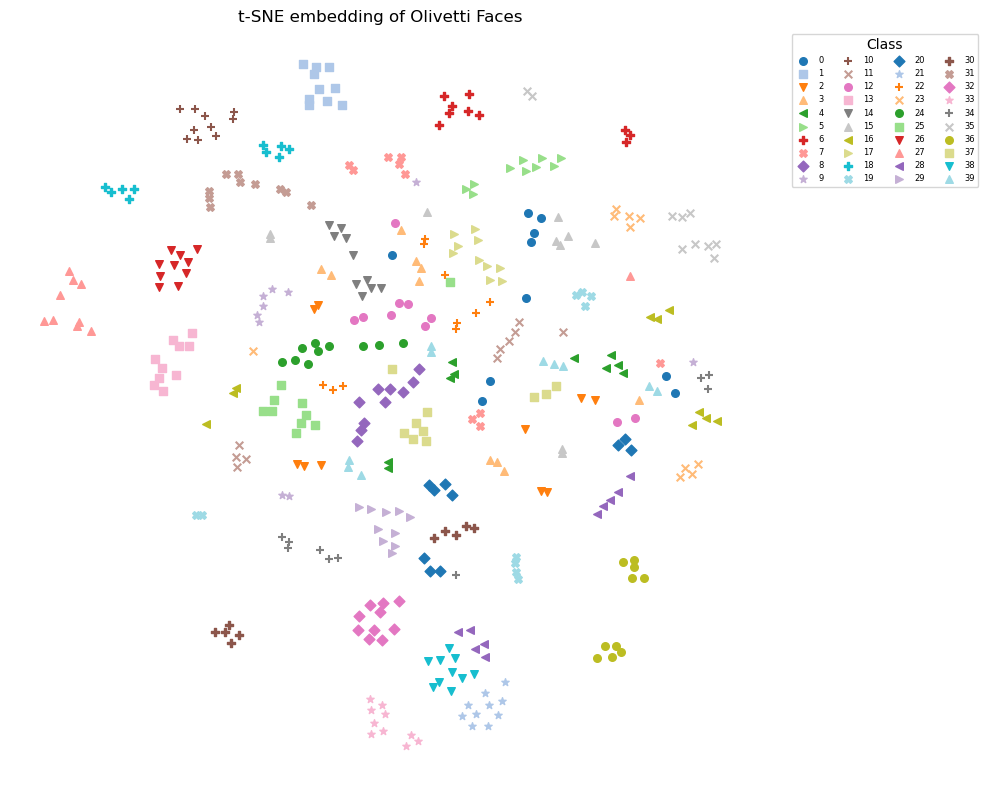

In [17]:
# Step 1: Load the dataset
data = np.load("Olivetti_faces/olivetti_faces.npy")
X = data.reshape(data.shape[0], -1)  # 400 faces of size 64x64
Y_target = np.load("Olivetti_faces/olivetti_faces_target.npy")  # Load labels

# Step 2: tSNE
Y_tsne = tsne(
    X,
    n_dims=2,          # project down to 2D
    perplexity=30.0,
    max_iter=1000,
    learning_rate=1000.0
)


# Step 3: Visualize the 2D embedding
import matplotlib.pyplot as plt

markers = ["o", "s", "v", "^", "<", ">", "P", "X", "D", "*", "+", "x"]  # 12 shapes
hues = plt.cm.tab20.colors  # 20 distinct colours
plt.figure(figsize=(10, 8))
for i, cls in enumerate(np.unique(Y_target)):
    xi = Y_tsne[Y_target == cls, 0]
    yi = Y_tsne[Y_target == cls, 1]
    m = markers[i % len(markers)]
    c = hues[i % len(hues)]
    plt.scatter(xi, yi, marker=m, facecolors=c, s=30, label=str(cls))
plt.legend(ncol=4, fontsize=6, title="Class", bbox_to_anchor=(1.05, 1))
plt.title("t-SNE embedding of Olivetti Faces")
plt.axis('off')
plt.tight_layout()
plt.show()

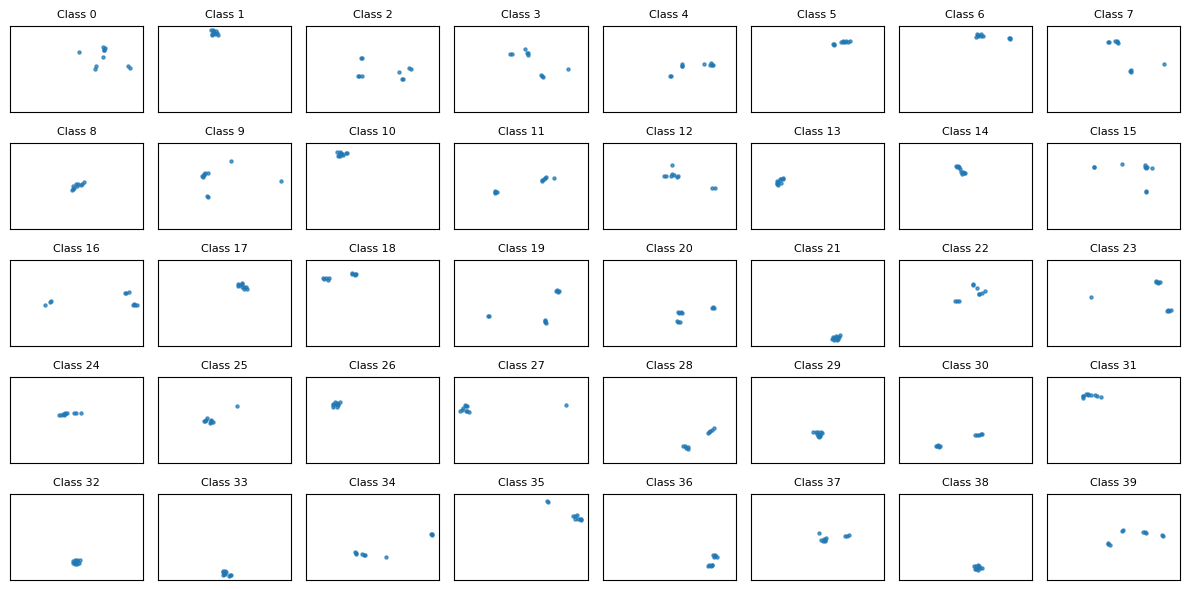

In [19]:
ncols = 8
nrows = int(np.ceil(len(np.unique(Y_target))/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6), sharex=True, sharey=True)
for cls, ax in zip(np.unique(Y_target), axes.flatten()):
    ax.scatter(Y_tsne[Y_target==cls,0], Y_tsne[Y_target==cls,1], s=5, alpha=0.7)
    ax.set_title(f"Class {cls}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()
